In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Cell 2: Load and Filter Dataset
df = pd.read_csv("5g_nidd.csv")

# Keep only UDP and TCP related attack types
df = df[df['Attack Type'].isin(['UDPFlood', 'UDPScan',
                               'HTTPFlood', 'SlowrateDoS', 'SYNFlood', 'SYNScan', 'TCPConnectScan',
                               'Benign'])]

# Separate features and labels
X = df.drop(columns=['Attack Type']).values
y = df['Attack Type'].values

/var/folders/45/0lfy6jf14g3cptljv3x_x53r0000gn/T/ipykernel_72617/4169188943.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("5g_nidd.csv")


In [3]:
# X preprocessing
scaler = MinMaxScaler()

# Keep only columns with numeric dtype in X
float_cols = [i for i, col in enumerate(df.drop(columns=['Attack Type']).columns) if df[col].dtype != str and df[col].dtype != 'object']
X_numeric = X[:, float_cols]

X_scaled = scaler.fit_transform(X_numeric)
X_scaled = np.nan_to_num(X_scaled, nan=0.0)


In [ ]:
# Calculate importance of features using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Use the scaled features and binary labels
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

X_udp_only = X_scaled[(y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan')]  # Use only TCP for feature importance
y_udp_only = y[(y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan')]
rf.fit(X_udp_only, y_udp_only)

importances = rf.feature_importances_

# Get feature names from df using float_cols
feature_names = df.drop(columns=['Attack Type']).columns[float_cols]

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Id': range(len(feature_names)),
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Keep only top 32 features by importance
top_features = feature_importance_df['Id'].iloc[:32].tolist()

print("Top 32 features:", top_features)
X_processed = X_scaled[:, top_features]

print(X_processed.shape)

    Id     Feature  Importance
10  10        sTtl    0.351139
12  12       sHops    0.259545
0    0  Unnamed: 0    0.184439
20  20      Offset    0.101699
1    1         Seq    0.058630
2    2         Dur    0.010306
7    7         Max    0.004373
4    4        Mean    0.004060
33  33     SrcRate    0.003975
32  32        Rate    0.003657
5    5         Sum    0.003457
3    3     RunTime    0.003111
14  14     TotPkts    0.002819
6    6         Min    0.001922
21  21  sMeanPktSz    0.001810
18  18    SrcBytes    0.001775
17  17    TotBytes    0.001267
23  23        Load    0.001133
24  24     SrcLoad    0.000752
13  13       dHops    0.000040
39  39  SrcTCPBase    0.000039
11  11        dTtl    0.000024
19  19    DstBytes    0.000015
15  15     SrcPkts    0.000006
16  16     DstPkts    0.000004
35  35      SrcWin    0.000003
40  40  DstTCPBase    0.000000
42  42      SynAck    0.000000
38  38        dVid    0.000000
37  37        sVid    0.000000
36  36      DstWin    0.000000
34  34  

In [5]:
# Y preprocessing
y_processed = np.where(y == 'Benign', 0, 1)

In [6]:
# Cell 4: Define the MLP Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [7]:
def meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred_train = model(x_meta_train)
    loss_train = loss_fn(y_pred_train, y_meta_train)

    # Forward pass on meta-test
    y_pred_test = model(x_meta_test)
    loss_test = loss_fn(y_pred_test, y_meta_test)

    # Combined loss
    loss = alpha * loss_train + (1 - alpha) * loss_test

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [8]:
def normal_train_step(model, x_train, y_train, optimizer):
    loss_fn = nn.BCELoss()

    # Forward pass on meta-train
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [9]:
# Get indices for each class in train
benign_index = np.where(y == 'Benign')[0]
udp_index = np.where((y == 'UDPFlood') | (y == 'UDPScan'))[0]
tcp_index = np.where((y == 'HTTPFlood') | (y == 'SlowrateDoS') | (y == 'SYNFlood') | (y == 'SYNScan') | (y == 'TCPConnectScan'))[0]

print("Benign size:", len(benign_index))
print("UDP size:", len(udp_index))
print("TCP size:", len(tcp_index))

# Split indices into train and test sets
train_udp_index = np.random.choice(udp_index, int(0.8 * len(udp_index)), replace=False)
test_udp_index = np.setdiff1d(udp_index, train_udp_index)

Benign size: 477737
UDP size: 473246
TCP size: 263752


In [10]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test)
    rng.shuffle(benign_index)
    rng.shuffle(tcp_index)
    rng.shuffle(train_udp_index)
    rng.shuffle(test_udp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, tcp_index])
    print(len(combined_index), "samples in combined index.")
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_tcp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_tcp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]
        
        # Meta-train: all UDPFlood + 80% Benign
        meta_train_index = np.concatenate([train_tcp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Count number of 0 and 1 in y_meta_train
        meta_train_num_zeros = (y_meta_train == 0).sum().item()
        meta_train_num_ones = (y_meta_train == 1).sum().item()
        print(f"y_meta_train: {meta_train_num_zeros} zeros, {meta_train_num_ones} ones")

        # Meta-test: len_meta_test samples from UDP + 20% Benign
        meta_test_index = np.concatenate([
            train_udp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Count number of 0 and 1 in y_meta_test
        meta_test_num_zeros = (y_meta_test == 0).sum().item()
        meta_test_num_ones = (y_meta_test == 1).sum().item()
        print(f"y_meta_test: {meta_test_num_zeros} zeros, {meta_test_num_ones} ones")

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=0.5)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for len_meta_test: 0
741489 samples in combined index.
y_meta_train: 305844 zeros, 210886 ones
y_meta_test: 76461 zeros, 0 ones
y_meta_train: 305713 zeros, 211049 ones
y_meta_test: 76429 zeros, 0 ones
y_meta_train: 305858 zeros, 210868 ones
y_meta_test: 76465 zeros, 0 ones
y_meta_train: 305570 zeros, 211228 ones
y_meta_test: 76393 zeros, 0 ones
y_meta_train: 305772 zeros, 210977 ones
y_meta_test: 76443 zeros, 0 ones
F1 Score: 0.7093 ± 0.0151
Running for len_meta_test: 1
741489 samples in combined index.
y_meta_train: 305844 zeros, 210886 ones
y_meta_test: 76461 zeros, 1 ones
y_meta_train: 305713 zeros, 211049 ones
y_meta_test: 76429 zeros, 1 ones
y_meta_train: 305858 zeros, 210868 ones
y_meta_test: 76465 zeros, 1 ones
y_meta_train: 305570 zeros, 211228 ones
y_meta_test: 76393 zeros, 1 ones
y_meta_train: 305772 zeros, 210977 ones
y_meta_test: 76443 zeros, 1 ones
F1 Score: 0.6980 ± 0.0061
Running for len_meta_test: 10
741489 samples in combined index.
y_meta_train: 305844 zeros, 

F1 Scores:
0.7093 ± 0.0151
0.6980 ± 0.0061
0.7677 ± 0.0238
0.9458 ± 0.0098
0.9866 ± 0.0021
0.9949 ± 0.0003
Precisions:
0.9984 ± 0.0011
0.9980 ± 0.0004
0.9988 ± 0.0010
0.9990 ± 0.0004
0.9989 ± 0.0008
0.9987 ± 0.0007
Recalls:
0.5502 ± 0.0183
0.5367 ± 0.0072
0.6241 ± 0.0323
0.8982 ± 0.0174
0.9747 ± 0.0044
0.9911 ± 0.0009


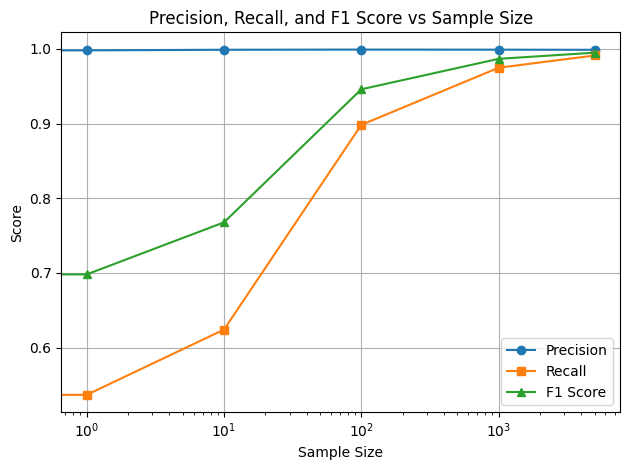

In [11]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs Sample Size')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
f1_scores = []
f1_scores_std = []
precisions = []
precisions_std = []
recalls = []
recalls_std = []

# Experiment with different alphas
for alpha in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    len_meta_test = 1000
    print(f"Running for alpha: {alpha}")
    
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=int(alpha * 1000))  # Use alpha to seed the RNG
    rng.shuffle(benign_index)
    rng.shuffle(udp_index)
    rng.shuffle(train_tcp_index)
    rng.shuffle(test_tcp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores = []
    fold_precisions = []
    fold_recalls = []

    combined_index = np.concatenate([benign_index, tcp_index])
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = train_index[np.where(y_processed[train_index] == 0)[0]]
        train_tcp_index = train_index[np.where(y_processed[train_index] == 1)[0]]
        test_benign_index = test_index[np.where(y_processed[test_index] == 0)[0]]
        test_tcp_index = test_index[np.where(y_processed[test_index] == 1)[0]]
        
        # Split into 80% and 20%
        n_train_benign_80 = int(0.8 * len(train_benign_index))
        train_benign_80_index = train_benign_index[:n_train_benign_80]
        train_benign_20_index = train_benign_index[n_train_benign_80:]

        # Meta-train: all TCP + 80% Benign
        meta_train_index = np.concatenate([train_tcp_index, train_benign_80_index])
        x_meta_train = torch.tensor(X_processed[meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[meta_train_index], dtype=torch.float32).unsqueeze(1)
        
        # Meta-test: len_meta_test samples from UDP + 20% Benign
        meta_test_index = np.concatenate([
            train_udp_index[:len_meta_test], 
            train_benign_20_index
        ])
        x_meta_test = torch.tensor(X_processed[meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[meta_test_index], dtype=torch.float32).unsqueeze(1)

        # Test set: 1000 samples from TCP, UDP and 2000 Benign
        test_index = np.concatenate([
            test_tcp_index[:1000], 
            test_udp_index[:1000], 
            test_benign_index[:2000]
        ])
        x_test = torch.tensor(X_processed[test_index], dtype=torch.float32)
        y_test = torch.tensor(y_processed[test_index], dtype=torch.float32).unsqueeze(1)

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Training
        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer, alpha=alpha)

        # Evaluation
        with torch.no_grad():
            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred)
            cm = confusion_matrix(y_test.numpy(), y_pred)
            precision = precision_score(y_test.numpy(), y_pred)
            recall = recall_score(y_test.numpy(), y_pred)

            fold_f1_scores.append(score)
            fold_precisions.append(precision)
            fold_recalls.append(recall)

    f1_scores.append(np.mean(fold_f1_scores))
    precisions.append(np.mean(fold_precisions))
    recalls.append(np.mean(fold_recalls))

    f1_scores_std.append(np.std(fold_f1_scores))
    precisions_std.append(np.std(fold_precisions))
    recalls_std.append(np.std(fold_recalls))

    print(f"F1 Score: {f1_scores[-1]:.4f} ± {f1_scores_std[-1]:.4f}")

Running for alpha: 0.0
F1 Score: 0.6469 ± 0.0052
Running for alpha: 0.1
F1 Score: 0.9901 ± 0.0017
Running for alpha: 0.2
F1 Score: 0.9920 ± 0.0011
Running for alpha: 0.3
F1 Score: 0.9896 ± 0.0010
Running for alpha: 0.4
F1 Score: 0.9897 ± 0.0008
Running for alpha: 0.5
F1 Score: 0.9878 ± 0.0020
Running for alpha: 0.6
F1 Score: 0.9869 ± 0.0007
Running for alpha: 0.7
F1 Score: 0.9842 ± 0.0017
Running for alpha: 0.8
F1 Score: 0.9779 ± 0.0013
Running for alpha: 0.9
F1 Score: 0.9654 ± 0.0090
Running for alpha: 1.0
F1 Score: 0.7142 ± 0.0122


F1 Scores:
0.6469 ± 0.0052
0.9901 ± 0.0017
0.9920 ± 0.0011
0.9896 ± 0.0010
0.9897 ± 0.0008
0.9878 ± 0.0020
0.9869 ± 0.0007
0.9842 ± 0.0017
0.9779 ± 0.0013
0.9654 ± 0.0090
0.7142 ± 0.0122
Precisions:
0.9996 ± 0.0005
0.9993 ± 0.0005
0.9995 ± 0.0005
0.9986 ± 0.0007
0.9985 ± 0.0006
0.9987 ± 0.0007
0.9989 ± 0.0002
0.9987 ± 0.0007
0.9978 ± 0.0012
0.9974 ± 0.0011
0.9973 ± 0.0012
Recalls:
0.4782 ± 0.0057
0.9811 ± 0.0031
0.9846 ± 0.0017
0.9808 ± 0.0015
0.9810 ± 0.0014
0.9772 ± 0.0035
0.9753 ± 0.0012
0.9702 ± 0.0035
0.9588 ± 0.0020
0.9355 ± 0.0161
0.5564 ± 0.0149


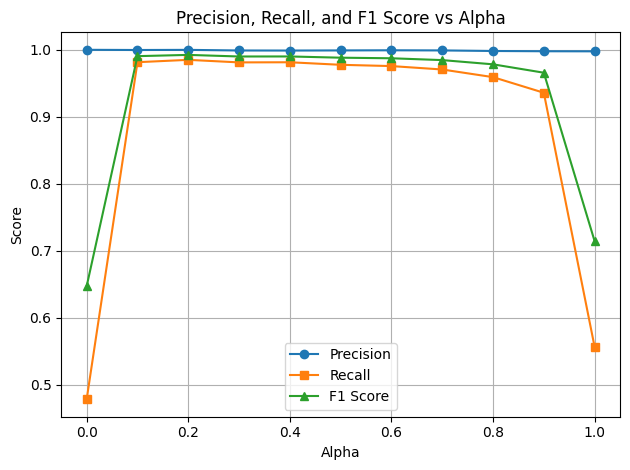

In [13]:
# Visualization
print("F1 Scores:")
for i in range(len(f1_scores)):
    print(f"{f1_scores[i]:.4f} ± {f1_scores_std[i]:.4f}")
    
print("Precisions:")
for i in range(len(precisions)):
    print(f"{precisions[i]:.4f} ± {precisions_std[i]:.4f}")
    
print("Recalls:")
for i in range(len(recalls)):
    print(f"{recalls[i]:.4f} ± {recalls_std[i]:.4f}")
    
x = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

plt.plot(x, precisions, marker='o', label='Precision')
plt.plot(x, recalls, marker='s', label='Recall')
plt.plot(x, f1_scores, marker='^', label='F1 Score')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
f1_scores_tcp = []
f1_scores_std_tcp = []
precisions_tcp = []
precisions_std_tcp = []
recalls_tcp = []
recalls_std_tcp = []

f1_scores_tcp_udp = []
f1_scores_std_tcp_udp = []
precisions_tcp_udp = []
precisions_std_tcp_udp = []
recalls_tcp_udp = []
recalls_std_tcp_udp = []

# Experiment with different number of meta-test samples
for len_meta_test in [0, 1, 10, 100, 1000, 5000]:
    print(f"Running for len_meta_test: {len_meta_test}")
    # Shuffle indices for random sampling
    rng = np.random.default_rng(seed=len_meta_test ** 2)
    rng.shuffle(benign_index)
    rng.shuffle(tcp_index)
    rng.shuffle(train_udp_index)
    rng.shuffle(test_udp_index)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_f1_scores_tcp = []
    fold_precisions_tcp = []
    fold_recalls_tcp = []
    
    fold_f1_scores_tcp_udp = []
    fold_precisions_tcp_udp = []
    fold_recalls_tcp_udp = []

    combined_index = np.concatenate([benign_index, tcp_index])
    print(len(combined_index), "samples in combined index.")
    print("Number of ones in y_processed[combined_index]:", np.sum(y_processed[combined_index] == 1))
    print("Number of zeros in y_processed[combined_index]:", np.sum(y_processed[combined_index] == 0))
    for fold, (train, test) in enumerate(kf.split(combined_index)):
        # Get indices for each class in train and test
        train_index = combined_index[train]
        test_index = combined_index[test]
        rng.shuffle(train_index)
        rng.shuffle(test_index)
        
        train_benign_index = np.intersect1d(train_index, benign_index)
        train_tcp_index = np.intersect1d(train_index, tcp_index)
        test_benign_index = np.intersect1d(test_index, benign_index)
        test_tcp_index = np.intersect1d(test_index, tcp_index)

        # Split into 50% and 50%    
        len_train_tcp_50 = int(0.50 * len(train_tcp_index))
        
        # Split into 33%, 33% and 34%    
        len_train_benign_33 = int(0.33 * len(train_benign_index))
        len_train_benign_66 = int(0.66 * len(train_benign_index))

        # Initialize model and training
        model = MLP(X_processed.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        #--------------------------------- Training with TCP only ---------------------------------------#
        # Train: 50% TCP + 50% Benign
        tcp_train_index = np.concatenate([train_tcp_index[:len_train_tcp_50], train_benign_index[:len_train_benign_33]])
        x_train = torch.tensor(X_processed[tcp_train_index], dtype=torch.float32)
        y_train = torch.tensor(y_processed[tcp_train_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[tcp_train_index]:", np.sum(y_processed[tcp_train_index] == 1))
        print("Number of zeros in y_processed[tcp_train_index]:", np.sum(y_processed[tcp_train_index] == 0))

        # Training with TCP only
        for epoch in range(1000):
            loss = normal_train_step(model, x_train, y_train, optimizer)

        # Evaluation with TCP only
        with torch.no_grad():
            tcp_test_index = np.concatenate([test_benign_index[:1000], test_tcp_index[:1000]])
            x_test = torch.tensor(X_processed[tcp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[tcp_test_index], dtype=torch.float32).unsqueeze(1)
            print("Number of ones in y_processed[tcp_test_index]:", np.sum(y_processed[tcp_test_index] == 1))
            print("Number of zeros in y_processed[tcp_test_index]:", np.sum(y_processed[tcp_test_index] == 0))

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred, zero_division=0)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred, zero_division=0)

            fold_f1_scores_tcp.append(score)
            fold_precisions_tcp.append(precision)
            fold_recalls_tcp.append(recall)


        #--------------------------------- Training with TCP and UDP ---------------------------------------#
        # Meta-train: 50% TCP + 25% Benign
        tcp_udp_meta_train_index = np.concatenate([train_tcp_index[len_train_tcp_50:], train_benign_index[len_train_benign_33:len_train_benign_66]])
        x_meta_train = torch.tensor(X_processed[tcp_udp_meta_train_index], dtype=torch.float32)
        y_meta_train = torch.tensor(y_processed[tcp_udp_meta_train_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[tcp_udp_meta_train_index]:", np.sum(y_processed[tcp_udp_meta_train_index] == 1))
        print("Number of zeros in y_processed[tcp_udp_meta_train_index]:", np.sum(y_processed[tcp_udp_meta_train_index] == 0))

        # Meta-test: len_meta_test samples from UDP and 15% Benign
        tcp_udp_meta_test_index = np.concatenate([
            train_udp_index[:len_meta_test], 
            train_benign_index[len_train_benign_66:]
        ])
        x_meta_test = torch.tensor(X_processed[tcp_udp_meta_test_index], dtype=torch.float32)
        y_meta_test = torch.tensor(y_processed[tcp_udp_meta_test_index], dtype=torch.float32).unsqueeze(1)
        print("Number of ones in y_processed[tcp_udp_meta_test_index]:", np.sum(y_processed[tcp_udp_meta_test_index] == 1))
        print("Number of zeros in y_processed[tcp_udp_meta_test_index]:", np.sum(y_processed[tcp_udp_meta_test_index] == 0))

        for epoch in range(1000):
            loss = meta_train_step(model, x_meta_train, y_meta_train, x_meta_test, y_meta_test, optimizer)
            
        # Evaluation
        with torch.no_grad():
            tcp_udp_test_index = np.concatenate([test_benign_index[:2000], test_udp_index[:1000], test_tcp_index[:1000]])
            x_test= torch.tensor(X_processed[tcp_udp_test_index], dtype=torch.float32)
            y_test = torch.tensor(y_processed[tcp_udp_test_index], dtype=torch.float32).unsqueeze(1)
            print("Number of ones in y_processed[tcp_udp_test_index]:", np.sum(y_processed[tcp_udp_test_index] == 1))
            print("Number of zeros in y_processed[tcp_udp_test_index]:", np.sum(y_processed[tcp_udp_test_index] == 0))

            y_pred = model(x_test).squeeze().round().numpy()
            score = f1_score(y_test.numpy(), y_pred, zero_division=0)
            precision = precision_score(y_test.numpy(), y_pred, zero_division=0)
            recall = recall_score(y_test.numpy(), y_pred, zero_division=0)

            fold_f1_scores_tcp_udp.append(score)
            fold_precisions_tcp_udp.append(precision)
            fold_recalls_tcp_udp.append(recall)
        

    f1_scores_tcp.append(np.mean(fold_f1_scores_tcp))
    precisions_tcp.append(np.mean(fold_precisions_tcp))
    recalls_tcp.append(np.mean(fold_recalls_tcp))
    f1_scores_std_tcp.append(np.std(fold_f1_scores_tcp))
    precisions_std_tcp.append(np.std(fold_precisions_tcp))
    recalls_std_tcp.append(np.std(fold_recalls_tcp))

    f1_scores_tcp_udp.append(np.mean(fold_f1_scores_tcp_udp))
    precisions_tcp_udp.append(np.mean(fold_precisions_tcp_udp))
    recalls_tcp_udp.append(np.mean(fold_recalls_tcp_udp))
    f1_scores_std_tcp_udp.append(np.std(fold_f1_scores_tcp_udp))
    precisions_std_tcp_udp.append(np.std(fold_precisions_tcp_udp))
    recalls_std_tcp_udp.append(np.std(fold_recalls_tcp_udp))

    print(f"F1 Score of M1 (UDP only): {f1_scores_tcp[-1]:.4f} ± {f1_scores_std_tcp[-1]:.4f}")
    print(f"F1 Score of M2 (UDP + TCP): {f1_scores_tcp_udp[-1]:.4f} ± {f1_scores_std_tcp_udp[-1]:.4f}")

Running for len_meta_test: 0
741489 samples in combined index.
Number of ones in y_processed[combined_index]: 263752
Number of zeros in y_processed[combined_index]: 477737
Number of ones in y_processed[tcp_train_index]: 105443
Number of zeros in y_processed[tcp_train_index]: 126160
Number of ones in y_processed[tcp_test_index]: 1000
Number of zeros in y_processed[tcp_test_index]: 1000
Number of ones in y_processed[tcp_udp_meta_train_index]: 105443
Number of zeros in y_processed[tcp_udp_meta_train_index]: 126161
Number of ones in y_processed[tcp_udp_meta_test_index]: 0
Number of zeros in y_processed[tcp_udp_meta_test_index]: 129984
Number of ones in y_processed[tcp_udp_test_index]: 2000
Number of zeros in y_processed[tcp_udp_test_index]: 2000
Number of ones in y_processed[tcp_train_index]: 105524
Number of zeros in y_processed[tcp_train_index]: 126106
Number of ones in y_processed[tcp_test_index]: 1000
Number of zeros in y_processed[tcp_test_index]: 1000
Number of ones in y_processed[tc

F1 Scores of M1 (UDP only):
F1 Scores:
0.9982 ± 0.0014
0.9969 ± 0.0032
0.9960 ± 0.0024
0.9975 ± 0.0017
0.9976 ± 0.0031
0.9975 ± 0.0015
Precisions:
1.0000 ± 0.0000
0.9998 ± 0.0004
0.9996 ± 0.0005
0.9998 ± 0.0004
0.9998 ± 0.0004
0.9998 ± 0.0004
Recalls:
0.9964 ± 0.0029
0.9940 ± 0.0066
0.9924 ± 0.0048
0.9952 ± 0.0034
0.9954 ± 0.0063
0.9952 ± 0.0032
F1 Scores of M2 (TCP + UDP):
F1 Scores:
0.6736 ± 0.0246
0.6807 ± 0.0076
0.7134 ± 0.0346
0.9595 ± 0.0134
0.9878 ± 0.0049
0.9958 ± 0.0020
Precisions:
0.9963 ± 0.0065
0.9987 ± 0.0013
0.9987 ± 0.0014
0.9994 ± 0.0006
0.9994 ± 0.0004
0.9990 ± 0.0006
Recalls:
0.5094 ± 0.0280
0.5164 ± 0.0088
0.5560 ± 0.0427
0.9231 ± 0.0247
0.9766 ± 0.0094
0.9926 ± 0.0036


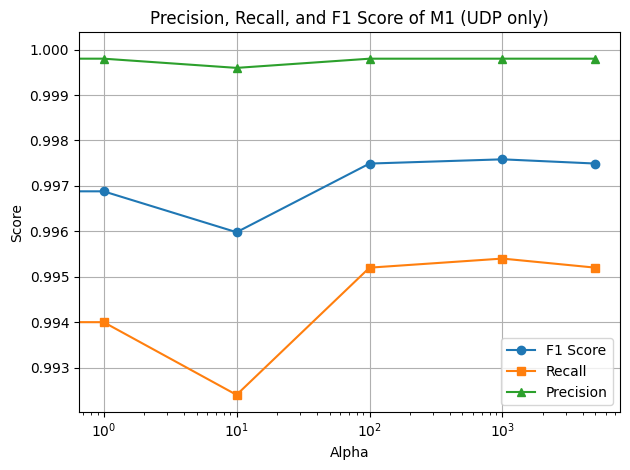

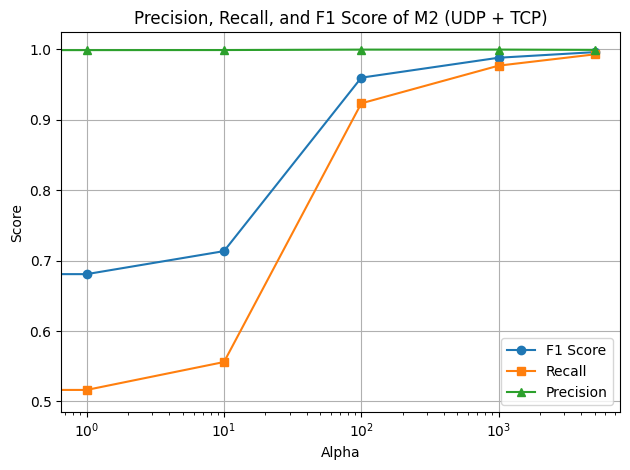

In [17]:
# Visualization
print("F1 Scores of M1 (UDP only):")
print("F1 Scores:")
for i in range(len(f1_scores_tcp)):
    print(f"{f1_scores_tcp[i]:.4f} ± {f1_scores_std_tcp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_tcp)):
    print(f"{precisions_tcp[i]:.4f} ± {precisions_std_tcp[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_tcp)):
    print(f"{recalls_tcp[i]:.4f} ± {recalls_std_tcp[i]:.4f}")

print("F1 Scores of M2 (TCP + UDP):")
print("F1 Scores:")
for i in range(len(f1_scores_tcp_udp)):
    print(f"{f1_scores_tcp_udp[i]:.4f} ± {f1_scores_std_tcp_udp[i]:.4f}")

print("Precisions:")
for i in range(len(precisions_tcp_udp)):
    print(f"{precisions_tcp_udp[i]:.4f} ± {precisions_std_tcp_udp[i]:.4f}")

print("Recalls:")
for i in range(len(recalls_tcp_udp)):
    print(f"{recalls_tcp_udp[i]:.4f} ± {recalls_std_tcp_udp[i]:.4f}")

x = [0, 1, 10, 100, 1000, 5000]

plt.plot(x, f1_scores_tcp, marker='o', label='F1 Score')
plt.plot(x, recalls_tcp, marker='s', label='Recall')
plt.plot(x, precisions_tcp, marker='^', label='Precision')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M1 (UDP only)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.plot(x, f1_scores_tcp_udp, marker='o', label='F1 Score')
plt.plot(x, recalls_tcp_udp, marker='s', label='Recall')
plt.plot(x, precisions_tcp_udp, marker='^', label='Precision')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score of M2 (UDP + TCP)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()